In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('monthly_milk_production.csv')

In [3]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [4]:
df.set_index('Date', inplace=True)

In [5]:
df.head()

,Production
Date,
1962-01,589
1962-02,561
1962-03,640
1962-04,656
1962-05,727


In [6]:
df.tail()

,Production
Date,
1975-08,858
1975-09,817
1975-10,827
1975-11,797
1975-12,843


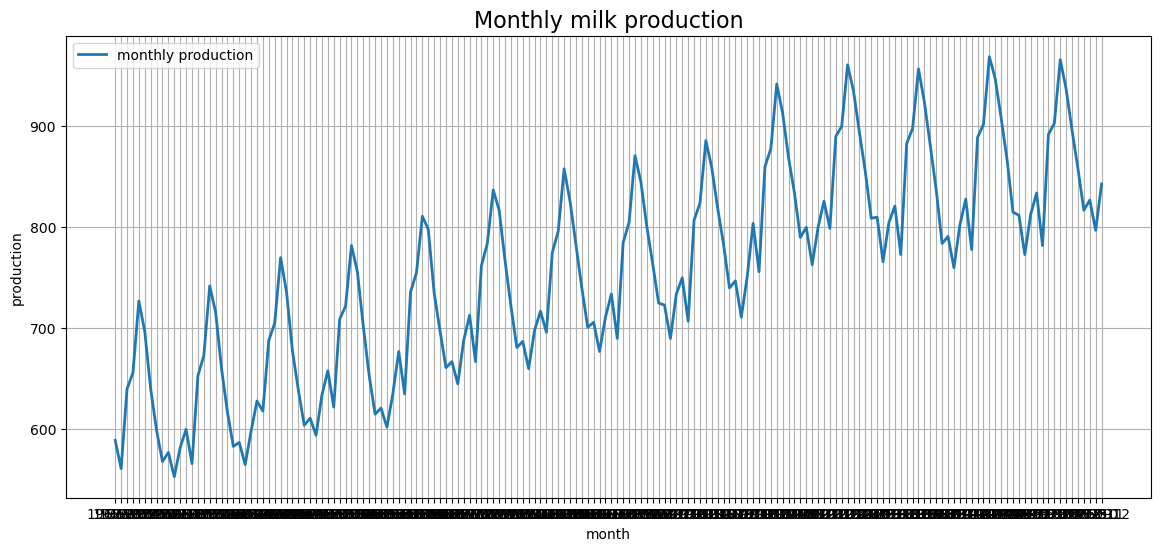

In [7]:
# Plot the daily energy consumption
import matplotlib.pyplot as plt
plt.figure(figsize=(14,6))
plt.plot(df['Production'], label='monthly production', linewidth=2)
plt.title('Monthly milk production', fontsize=16)
plt.xlabel('month')
plt.ylabel('production')
plt.legend()
plt.grid(True)
plt.show()


In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Use only 'Consumption (kWh)' for forecasting
milk =df[['Production']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
milk_scaled = scaler.fit_transform(milk)

In [9]:
X = []
y = []
n_steps = 30

for i in range(n_steps, len(milk_scaled)):
    X.append(milk_scaled[i-n_steps:i, 0])
    y.append(milk_scaled[i, 0])

X, y = np.array(X), np.array(y)

X.shape, y.shape

((138, 30), (138,))

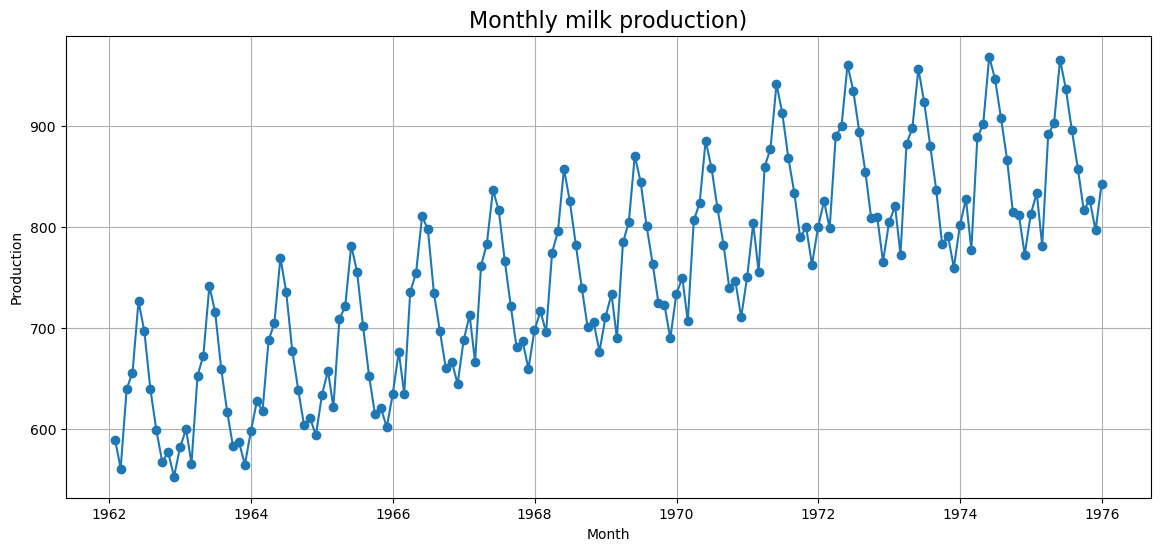

In [10]:
df.index = pd.to_datetime(df.index)

# Resample to monthly frequency and calculate the mean
monthly_avg = df['Production'].resample('ME').mean()

# Plot
plt.figure(figsize=(14,6))
plt.plot(monthly_avg, marker='o', linestyle='-')
plt.title('Monthly milk production)', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Production')
plt.grid(True)
plt.show()

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense,LSTM


# Build RNN Model
basic_rnn= Sequential()
basic_rnn.add(SimpleRNN(50, activation='tanh', input_shape=(X.shape[1], 1)))
basic_rnn.add(Dense(1))


C:\Users\Lenovo\python_practise\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [12]:
basic_rnn.compile(optimizer='adam', loss='mse')

In [13]:
# Train basic RNN model
history = basic_rnn.fit(X, y, epochs=40, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 219ms/step - loss: 0.0964 - val_loss: 0.0291
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.0322 - val_loss: 0.0107
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0096 - val_loss: 0.0252
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0091 - val_loss: 0.0041
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0069 - val_loss: 0.0030
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0041 - val_loss: 0.0074
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0038 - val_loss: 0.0090
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0030 - val_loss: 0.0033
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0029 - val_loss: 0.0027
Epoch 10/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0020 - val_loss: 0.0042
Epoch 11/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 0.0020 - val_loss: 0.0038
Epoch 12/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 0.0019 - val_loss: 0.0021


In [14]:
n_future = 12

# Start with the last 30 months (scaled)
window = milk_scaled[-30:].copy()   # shape (30, 1)

predictions_scaled = []

for i in range(n_future):
    # Reshape to (1, 30, 1) for the model
    input_data = window.reshape((1, n_steps, 1))

    # Predict next value (scaled)
    pred_scaled = basic_rnn.predict(input_data, verbose=0)[0, 0]
    predictions_scaled.append(pred_scaled)

    # Slide the window: drop the oldest, append the new prediction
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# Convert all 12 predictions back to original scale
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
)

print("Predicted production for next 12 months:")
for i, val in enumerate(predictions.flatten(), 1):
    print(f"Month {i}: {val:.2f} liters")

Predicted production for next 12 months:
Month 1: 839.89 liters
Month 2: 817.38 liters
Month 3: 896.88 liters
Month 4: 905.66 liters
Month 5: 955.40 liters
Month 6: 950.95 liters
Month 7: 912.63 liters
Month 8: 877.34 liters
Month 9: 826.03 liters
Month 10: 833.45 liters
Month 11: 799.73 liters
Month 12: 831.36 liters


In [72]:
# 1. Define how many months to test (hold-out)
n_test = 12

# 2. Get the true last 12 months (scaled)
test_scaled = milk_scaled[-n_test:]  # shape (12, 1)

# 3. Get the 30 months just BEFORE the test period as the starting window
start_index = len(milk_scaled) - n_test - n_steps  # 168 - 12 - 30 = 126
window = milk_scaled[start_index : start_index + n_steps].copy()  # shape (30, 1)

# 4. Recursively predict those 12 months
forecast_scaled = []
for i in range(n_test):
    input_data = window.reshape((1, n_steps, 1))
    pred_scaled = basic_rnn.predict(input_data, verbose=0)[0, 0]
    forecast_scaled.append(pred_scaled)
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# 5. Convert both to original scale
test = scaler.inverse_transform(test_scaled)
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# 6. Now run your metric code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

smape_val = smape(test, forecast)

print("="*40)
print("EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)")
print("="*40)
print(f"MAE   (Mean Absolute Error) : {mae:.4f}")
print(f"RMSE  (Root Mean Sq Error)  : {rmse:.4f}")
print(f"sMAPE (Symmetric MAPE)      : {smape_val:.2f}%")
print("="*40)

EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)
MAE   (Mean Absolute Error) : 10.1885
RMSE  (Root Mean Sq Error)  : 14.8484
sMAPE (Symmetric MAPE)      : 1.22%


## tuned RNN model

In [16]:
tuned_rnn= Sequential()
tuned_rnn.add(SimpleRNN(50, activation='relu', input_shape=(X.shape[1], 1)))
tuned_rnn.add(Dense(1))

In [17]:
tuned_rnn.compile(optimizer='adam', loss='mse')

In [18]:
# Train tuned RNN model
history = tuned_rnn.fit(X, y, epochs=50, batch_size=16, validation_split=0.4, verbose=1)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 140ms/step - loss: 0.0963 - val_loss: 0.0790
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0245 - val_loss: 0.0357
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 0.0276 - val_loss: 0.0186
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0165 - val_loss: 0.0218
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0150 - val_loss: 0.0169
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0129 - val_loss: 0.0132
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0112 - val_loss: 0.0121
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0101 - val_loss: 0.0109
Epoch 9/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0092 - val_loss: 0.0075
Epoch 10/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.0085 - val_loss: 0.0068
Epoch 11/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0073 - val_loss: 0.0071
Epoch 12/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0070 - val_loss: 0.0058


In [19]:
n_future = 12

# Start with the last 30 months (scaled)
window = milk_scaled[-30:].copy()   # shape (30, 1)

predictions_scaled = []

for i in range(n_future):
    # Reshape to (1, 30, 1) for the model
    input_data = window.reshape((1, n_steps, 1))

    # Predict next value (scaled)
    pred_scaled = tuned_rnn.predict(input_data, verbose=0)[0, 0]
    predictions_scaled.append(pred_scaled)

    # Slide the window: drop the oldest, append the new prediction
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# Convert all 12 predictions back to original scale
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
)

print("Predicted production for next 12 months:")
for i, val in enumerate(predictions.flatten(), 1):
    print(f"Month {i}: {val:.2f} liters")

Predicted production for next 12 months:
Month 1: 830.96 liters
Month 2: 852.71 liters
Month 3: 908.32 liters
Month 4: 950.88 liters
Month 5: 983.66 liters
Month 6: 961.54 liters
Month 7: 909.73 liters
Month 8: 855.28 liters
Month 9: 821.03 liters
Month 10: 808.20 liters
Month 11: 808.01 liters
Month 12: 819.10 liters


In [73]:
# 1. Define how many months to test (hold-out)
n_test = 12

# 2. Get the true last 12 months (scaled)
test_scaled = milk_scaled[-n_test:]  # shape (12, 1)

# 3. Get the 30 months just BEFORE the test period as the starting window
start_index = len(milk_scaled) - n_test - n_steps  # 168 - 12 - 30 = 126
window = milk_scaled[start_index : start_index + n_steps].copy()  # shape (30, 1)

# 4. Recursively predict those 12 months
forecast_scaled = []
for i in range(n_test):
    input_data = window.reshape((1, n_steps, 1))
    pred_scaled = tuned_rnn.predict(input_data, verbose=0)[0, 0]
    forecast_scaled.append(pred_scaled)
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# 5. Convert both to original scale
test = scaler.inverse_transform(test_scaled)
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# 6. Now run your metric code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

smape_val = smape(test, forecast)

print("="*40)
print("EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)")
print("="*40)
print(f"MAE   (Mean Absolute Error) : {mae:.4f}")
print(f"RMSE  (Root Mean Sq Error)  : {rmse:.4f}")
print(f"sMAPE (Symmetric MAPE)      : {smape_val:.2f}%")
print("="*40)

EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)
MAE   (Mean Absolute Error) : 12.1210
RMSE  (Root Mean Sq Error)  : 16.3868
sMAPE (Symmetric MAPE)      : 1.37%


## building LSTM model

In [20]:
basic_lstm = Sequential()
basic_lstm.add(LSTM(50, activation='tanh', input_shape=(X.shape[1], 1)))
basic_lstm.add(Dense(1))
basic_lstm.compile(optimizer='adam', loss='mse')

C:\Users\Lenovo\python_practise\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [21]:
# Train basic lstm model
history = basic_lstm.fit(X, y, epochs=40, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 276ms/step - loss: 0.2372 - val_loss: 0.2888
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - loss: 0.1387 - val_loss: 0.1366
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0644 - val_loss: 0.0340
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - loss: 0.0260 - val_loss: 0.0575
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0404 - val_loss: 0.0476
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0288 - val_loss: 0.0242
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0253 - val_loss: 0.0294
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0271 - val_loss: 0.0305
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.0268 - val_loss: 0.0265
Epoch 10/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.0251 - val_loss: 0.0241
Epoch 11/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0243 - val_loss: 0.0249
Epoch 12/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 0.0242 - val_loss: 0.0246


In [22]:
n_future = 12

# Start with the last 30 months (scaled)
window = milk_scaled[-30:].copy()   # shape (30, 1)

predictions_scaled = []

for i in range(n_future):
    # Reshape to (1, 30, 1) for the model
    input_data = window.reshape((1, n_steps, 1))

    # Predict next value (scaled)
    pred_scaled = basic_lstm.predict(input_data, verbose=0)[0, 0]
    predictions_scaled.append(pred_scaled)

    # Slide the window: drop the oldest, append the new prediction
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# Convert all 12 predictions back to original scale
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
)

print("Predicted production for next 12 months:")
for i, val in enumerate(predictions.flatten(), 1):
    print(f"Month {i}: {val:.2f} liters")

Predicted production for next 12 months:
Month 1: 861.79 liters
Month 2: 863.12 liters
Month 3: 864.04 liters
Month 4: 865.02 liters
Month 5: 865.94 liters
Month 6: 866.91 liters
Month 7: 867.75 liters
Month 8: 868.50 liters
Month 9: 869.40 liters
Month 10: 869.98 liters
Month 11: 870.54 liters
Month 12: 870.93 liters


In [74]:
# 1. Define how many months to test (hold-out)
n_test = 12

# 2. Get the true last 12 months (scaled)
test_scaled = milk_scaled[-n_test:]  # shape (12, 1)

# 3. Get the 30 months just BEFORE the test period as the starting window
start_index = len(milk_scaled) - n_test - n_steps  # 168 - 12 - 30 = 126
window = milk_scaled[start_index : start_index + n_steps].copy()  # shape (30, 1)

# 4. Recursively predict those 12 months
forecast_scaled = []
for i in range(n_test):
    input_data = window.reshape((1, n_steps, 1))
    pred_scaled = basic_lstm.predict(input_data, verbose=0)[0, 0]
    forecast_scaled.append(pred_scaled)
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# 5. Convert both to original scale
test = scaler.inverse_transform(test_scaled)
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# 6. Now run your metric code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

smape_val = smape(test, forecast)

print("="*40)
print("EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)")
print("="*40)
print(f"MAE   (Mean Absolute Error) : {mae:.4f}")
print(f"RMSE  (Root Mean Sq Error)  : {rmse:.4f}")
print(f"sMAPE (Symmetric MAPE)      : {smape_val:.2f}%")
print("="*40)

EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)
MAE   (Mean Absolute Error) : 25.9602
RMSE  (Root Mean Sq Error)  : 31.4545
sMAPE (Symmetric MAPE)      : 3.08%


tuned lstm model

In [23]:
tuned_lstm = Sequential()
tuned_lstm.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
tuned_lstm.add(Dense(1))
tuned_lstm.compile(optimizer='adam', loss='mse')

C:\Users\Lenovo\python_practise\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [24]:
# Train tuned lstm model
history = tuned_lstm.fit(X, y, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - loss: 0.2525 - val_loss: 0.3622
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1772 - val_loss: 0.2459
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.1155 - val_loss: 0.1384
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0588 - val_loss: 0.0334
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.0278 - val_loss: 0.0546
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0259 - val_loss: 0.0232
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0236 - val_loss: 0.0239
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0225 - val_loss: 0.0227
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0220 - val_loss: 0.0250
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0221 - val_loss: 0.0239
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - loss: 0.0216 - val_loss: 0.0226
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0217 - val_loss: 0.0229


In [25]:
n_future = 12

# Start with the last 30 months (scaled)
window = milk_scaled[-30:].copy()   # shape (30, 1)

predictions_scaled = []

for i in range(n_future):
    # Reshape to (1, 30, 1) for the model
    input_data = window.reshape((1, n_steps, 1))

    # Predict next value (scaled)
    pred_scaled = tuned_lstm.predict(input_data, verbose=0)[0, 0]
    predictions_scaled.append(pred_scaled)

    # Slide the window: drop the oldest, append the new prediction
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# Convert all 12 predictions back to original scale
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
)

print("Predicted production for next 12 months:")
for i, val in enumerate(predictions.flatten(), 1):
    print(f"Month {i}: {val:.2f} liters")

Predicted production for next 12 months:
Month 1: 885.10 liters
Month 2: 910.15 liters
Month 3: 926.89 liters
Month 4: 935.91 liters
Month 5: 943.47 liters
Month 6: 941.99 liters
Month 7: 908.69 liters
Month 8: 834.23 liters
Month 9: 782.26 liters
Month 10: 759.75 liters
Month 11: 790.26 liters
Month 12: 840.03 liters


In [76]:
# 1. Define how many months to test (hold-out)
n_test = 12

# 2. Get the true last 12 months (scaled)
test_scaled = milk_scaled[-n_test:]  # shape (12, 1)

# 3. Get the 30 months just BEFORE the test period as the starting window
start_index = len(milk_scaled) - n_test - n_steps  # 168 - 12 - 30 = 126
window = milk_scaled[start_index : start_index + n_steps].copy()  # shape (30, 1)

# 4. Recursively predict those 12 months
forecast_scaled = []
for i in range(n_test):
    input_data = window.reshape((1, n_steps, 1))
    pred_scaled = tuned_lstm.predict(input_data, verbose=0)[0, 0]
    forecast_scaled.append(pred_scaled)
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# 5. Convert both to original scale
test = scaler.inverse_transform(test_scaled)
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# 6. Now run your metric code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

smape_val = smape(test, forecast)

print("="*40)
print("EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)")
print("="*40)
print(f"MAE   (Mean Absolute Error) : {mae:.4f}")
print(f"RMSE  (Root Mean Sq Error)  : {rmse:.4f}")
print(f"sMAPE (Symmetric MAPE)      : {smape_val:.2f}%")
print("="*40)

EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)
MAE   (Mean Absolute Error) : 305.2982
RMSE  (Root Mean Sq Error)  : 310.3263
sMAPE (Symmetric MAPE)      : 42.77%


# GRU model

In [60]:
from tensorflow.keras.layers import GRU

basic_gru = Sequential()
basic_gru.add(GRU(50, activation='tanh', input_shape=(X.shape[1], 1)))
basic_gru.add(Dense(1))
basic_gru.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
# Train basic gru model
history = basic_gru.fit(X, y, epochs=40, batch_size=32, validation_split=0.2, verbose=1)

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 127ms/step - loss: 0.0124 - val_loss: 0.0121
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0118 - val_loss: 0.0112
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0119 - val_loss: 0.0112
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0115 - val_loss: 0.0112
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0114 - val_loss: 0.0111
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0112 - val_loss: 0.0113
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0111 - val_loss: 0.0108
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0108 - val_loss: 0.0104
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.0110 - val_loss: 0.0103
Epoch 10/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0104 - val_loss: 0.0112
Epoch 11/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.0114 - val_loss: 0.0117
Epoch 12/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0103 - val_loss: 0.0100


In [69]:
n_future = 12

# Start with the last 30 months (scaled)
window = milk_scaled[-30:].copy()   # shape (30, 1)

predictions_scaled = []

for i in range(n_future):
    # Reshape to (1, 30, 1) for the model
    input_data = window.reshape((1, n_steps, 1))

    # Predict next value (scaled)
    pred_scaled = basic_gru.predict(input_data, verbose=0)[0, 0]
    predictions_scaled.append(pred_scaled)

    # Slide the window: drop the oldest, append the new prediction
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# Convert all 12 predictions back to original scale
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
)

print("Predicted production for next 12 months:")
for i, val in enumerate(predictions.flatten(), 1):
    print(f"Month {i}: {val:.2f} liters")

Predicted production for next 12 months:
Month 1: 850.26 liters
Month 2: 865.96 liters
Month 3: 870.90 liters
Month 4: 868.02 liters
Month 5: 860.88 liters
Month 6: 854.04 liters
Month 7: 849.78 liters
Month 8: 848.67 liters
Month 9: 850.36 liters
Month 10: 853.10 liters
Month 11: 855.81 liters
Month 12: 857.29 liters


In [77]:
# 1. Define how many months to test (hold-out)
n_test = 12

# 2. Get the true last 12 months (scaled)
test_scaled = milk_scaled[-n_test:]  # shape (12, 1)

# 3. Get the 30 months just BEFORE the test period as the starting window
start_index = len(milk_scaled) - n_test - n_steps  # 168 - 12 - 30 = 126
window = milk_scaled[start_index : start_index + n_steps].copy()  # shape (30, 1)

# 4. Recursively predict those 12 months
forecast_scaled = []
for i in range(n_test):
    input_data = window.reshape((1, n_steps, 1))
    pred_scaled = basic_gru.predict(input_data, verbose=0)[0, 0]
    forecast_scaled.append(pred_scaled)
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# 5. Convert both to original scale
test = scaler.inverse_transform(test_scaled)
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# 6. Now run your metric code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

smape_val = smape(test, forecast)

print("="*40)
print("EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)")
print("="*40)
print(f"MAE   (Mean Absolute Error) : {mae:.4f}")
print(f"RMSE  (Root Mean Sq Error)  : {rmse:.4f}")
print(f"sMAPE (Symmetric MAPE)      : {smape_val:.2f}%")
print("="*40)

EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)
MAE   (Mean Absolute Error) : 40.5242
RMSE  (Root Mean Sq Error)  : 49.7180
sMAPE (Symmetric MAPE)      : 4.68%


tuned GRU

In [65]:


btuned_gru = Sequential()
btuned_gru.add(GRU(50, activation='relu', input_shape=(X.shape[1], 1)))
btuned_gru.add(Dense(1))
btuned_gru.compile(optimizer='adam', loss='mse')

In [70]:
# Train tuned gru model
history = btuned_gru.fit(X, y, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0157 - val_loss: 0.0157
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0154 - val_loss: 0.0145
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0149 - val_loss: 0.0145
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0146 - val_loss: 0.0146
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0141 - val_loss: 0.0135
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0138 - val_loss: 0.0124
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0135 - val_loss: 0.0128
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0130 - val_loss: 0.0123
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0127 - val_loss: 0.0119
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0122 - val_loss: 0.0111
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0119 - val_loss: 0.0105
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0113 - val_loss: 0.0112
E

In [71]:
n_future = 12

# Start with the last 30 months (scaled)
window = milk_scaled[-30:].copy()   # shape (30, 1)

predictions_scaled = []

for i in range(n_future):
    # Reshape to (1, 30, 1) for the model
    input_data = window.reshape((1, n_steps, 1))

    # Predict next value (scaled)
    pred_scaled = btuned_gru.predict(input_data, verbose=0)[0, 0]
    predictions_scaled.append(pred_scaled)

    # Slide the window: drop the oldest, append the new prediction
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# Convert all 12 predictions back to original scale
predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
)

print("Predicted production for next 12 months:")
for i, val in enumerate(predictions.flatten(), 1):
    print(f"Month {i}: {val:.2f} liters")

Predicted production for next 12 months:
Month 1: 847.31 liters
Month 2: 869.87 liters
Month 3: 883.52 liters
Month 4: 890.36 liters
Month 5: 888.00 liters
Month 6: 878.14 liters
Month 7: 863.63 liters
Month 8: 848.94 liters
Month 9: 838.89 liters
Month 10: 835.11 liters
Month 11: 838.59 liters
Month 12: 847.20 liters


In [78]:
# 1. Define how many months to test (hold-out)
n_test = 12

# 2. Get the true last 12 months (scaled)
test_scaled = milk_scaled[-n_test:]  # shape (12, 1)

# 3. Get the 30 months just BEFORE the test period as the starting window
start_index = len(milk_scaled) - n_test - n_steps  # 168 - 12 - 30 = 126
window = milk_scaled[start_index : start_index + n_steps].copy()  # shape (30, 1)

# 4. Recursively predict those 12 months
forecast_scaled = []
for i in range(n_test):
    input_data = window.reshape((1, n_steps, 1))
    pred_scaled = btuned_gru.predict(input_data, verbose=0)[0, 0]
    forecast_scaled.append(pred_scaled)
    window = np.append(window[1:], [[pred_scaled]], axis=0)

# 5. Convert both to original scale
test = scaler.inverse_transform(test_scaled)
forecast = scaler.inverse_transform(np.array(forecast_scaled).reshape(-1, 1))

# 6. Now run your metric code
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))

def smape(y_true, y_pred):
    return 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))

smape_val = smape(test, forecast)

print("="*40)
print("EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)")
print("="*40)
print(f"MAE   (Mean Absolute Error) : {mae:.4f}")
print(f"RMSE  (Root Mean Sq Error)  : {rmse:.4f}")
print(f"sMAPE (Symmetric MAPE)      : {smape_val:.2f}%")
print("="*40)

EVALUATION METRICS ON LAST 12 MONTHS (HOLD-OUT)
MAE   (Mean Absolute Error) : 25.4239
RMSE  (Root Mean Sq Error)  : 33.0341
sMAPE (Symmetric MAPE)      : 2.94%


### I have 6 model 2 of rnnn ,2 of lstm,2 of gru,  2 nd models are tuned with the activation of 'relu'  

#

###

In [81]:
import pandas as pd

# Metrics copied from your notebook outputs
data = {
    'Model': ['Basic RNN', 'Tuned RNN', 'Basic LSTM', 'Tuned LSTM', 'Basic GRU', 'Tuned GRU'],
    'MAE':      [10.1885,   12.1210,    25.9602,     305.2982,    40.5242,    25.4239],
    'RMSE':     [14.8484,   16.3868,    31.4545,     310.3263,    49.7180,    33.0341],
    'sMAPE (%)':[1.22,      1.37,       3.08,        42.77,       4.68,       2.94]
}

# Create DataFrame
df_metrics = pd.DataFrame(data)

# Sort by MAE (lowest is best)
df_sorted = df_metrics.sort_values(by='MAE').reset_index(drop=True)

print("="*65)
print("MODEL PERFORMANCE COMPARISON (Hold-Out 12 Months)")
print("="*65)
print(df_sorted.to_string(index=False))
print("="*65)

# Highlight the winner
best_model = df_sorted.iloc[0]
print(f"\n✅ BEST PERFORMING MODEL: {best_model['Model']}")
print(f"   └─ MAE   : {best_model['MAE']:.4f}")
print(f"   └─ RMSE  : {best_model['RMSE']:.4f}")
print(f"   └─ sMAPE : {best_model['sMAPE (%)']:.2f}%")

MODEL PERFORMANCE COMPARISON (Hold-Out 12 Months)
     Model      MAE     RMSE  sMAPE (%)
 Basic RNN  10.1885  14.8484       1.22
 Tuned RNN  12.1210  16.3868       1.37
 Tuned GRU  25.4239  33.0341       2.94
Basic LSTM  25.9602  31.4545       3.08
 Basic GRU  40.5242  49.7180       4.68
Tuned LSTM 305.2982 310.3263      42.77

✅ BEST PERFORMING MODEL: Basic RNN
   └─ MAE   : 10.1885
   └─ RMSE  : 14.8484
   └─ sMAPE : 1.22%


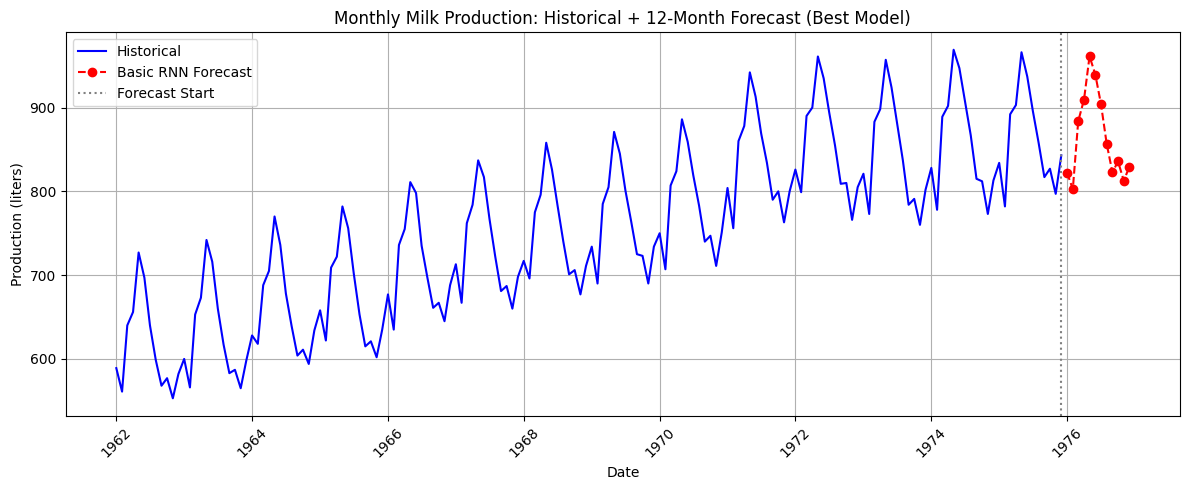

In [82]:
# === PLOT HISTORICAL + 12-MONTH FORECAST (Basic RNN) ===
import matplotlib.pyplot as plt

# Generate future dates
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1),
                             periods=12, freq='MS')

# Re-run basic_rnn forecast (or reuse your predictions_scaled from earlier)
# If you already have 'predictions' from basic_rnn, use it directly.
# Otherwise, re-run the loop:

window = milk_scaled[-30:].copy()
future_scaled = []
for i in range(12):
    inp = window.reshape((1, 30, 1))
    pred = basic_rnn.predict(inp, verbose=0)[0, 0]
    future_scaled.append(pred)
    window = np.append(window[1:], [[pred]], axis=0)

future_forecast = scaler.inverse_transform(np.array(future_scaled).reshape(-1, 1))

# Plot
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Production'], label='Historical', color='blue')
plt.plot(future_dates, future_forecast, label='Basic RNN Forecast',
         marker='o', linestyle='--', color='red')
plt.axvline(x=last_date, color='gray', linestyle=':', label='Forecast Start')
plt.title('Monthly Milk Production: Historical + 12-Month Forecast (Best Model)')
plt.xlabel('Date')
plt.ylabel('Production (liters)')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Basic RNN: this is the best model for this datasetSimple RNNs with tanh are less prone to overfitting.
###Tuned RNN: Worse than basic – relu + tuning caused slight overfitting.
###Basic GRU: GRU overcomplicates a small dataset (138 samples).
###Tuned GRU: Better than basic GRU, still worse than simple RNN.
###Basic LSTM: LSTM too heavy for this small, seasonal dataset.
###Tuned LSTM: worse relu + small data caused exploding gradients / instability.